In [1]:
import ast
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, roc_auc_score


In [2]:
processed_dir = Path("../data/processed")
figures_dir = Path("../figures")
results_dir = Path("../results")
models_dir = Path("../models")

figures_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)


In [3]:
metric_files = [
    results_dir / "knn_metrics.csv",
    results_dir / "logistic_metrics.csv",
    results_dir / "decision_tree_metrics.csv",
    results_dir / "random_forest_metrics.csv"
]

metrics = pd.concat([pd.read_csv(file) for file in metric_files], ignore_index=True)
comparison_columns = ["model", "accuracy", "precision", "recall", "f1", "roc_auc", "cv_mean", "cv_std"]
final_model_comparison = metrics[comparison_columns].copy()
final_model_comparison = final_model_comparison.sort_values(["roc_auc", "f1", "accuracy"], ascending=False).reset_index(drop=True)
final_model_comparison


,model,accuracy,precision,recall,f1,roc_auc,cv_mean,cv_std
0,Logistic Regression,0.831522,0.851485,0.843137,0.847291,0.913439,0.827413,0.034718
1,Random Forest,0.809783,0.831683,0.823529,0.827586,0.904830,0.832901,0.036042
2,KNN,0.847826,0.842593,0.892157,0.866667,0.902080,0.850561,0.028110
3,Decision Tree,0.760870,0.773585,0.803922,0.788462,0.755619,0.759542,0.020936


In [4]:
best_model = final_model_comparison.iloc[0]
best_model


model        Logistic Regression
accuracy                0.831522
precision               0.851485
recall                  0.843137
f1                      0.847291
roc_auc                 0.913439
cv_mean                 0.827413
cv_std                  0.034718
Name: 0, dtype: object

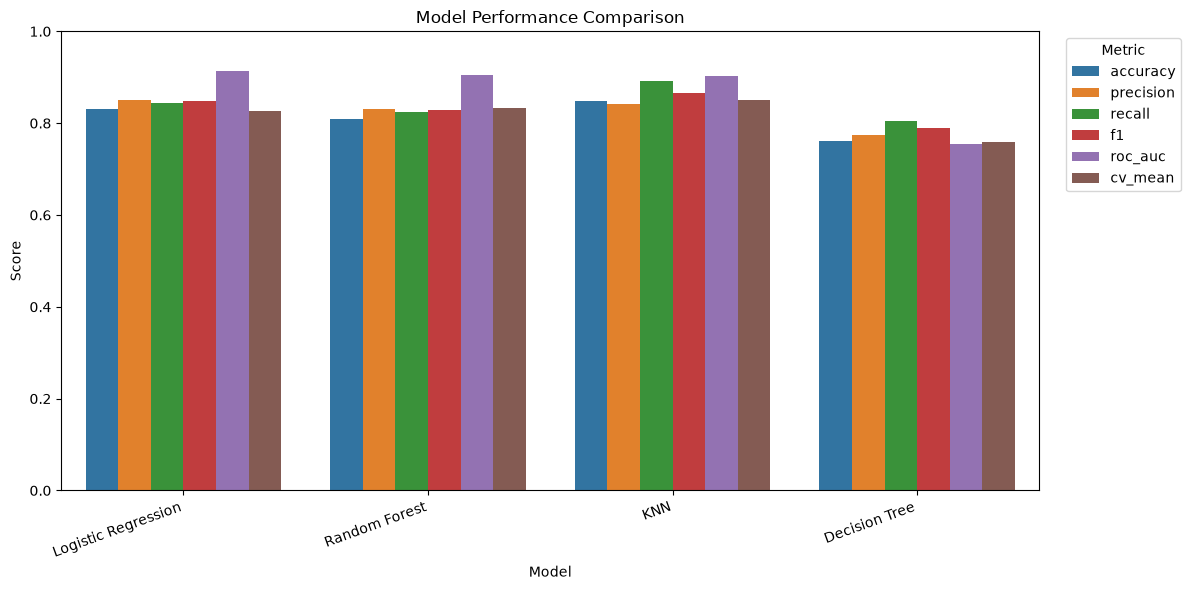

In [5]:
plot_data = final_model_comparison.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1", "roc_auc", "cv_mean"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_data, x="model", y="score", hue="metric")
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(figures_dir / "model_comparison.png", dpi=300)
plt.show()


In [6]:
heart_final = pd.read_csv(processed_dir / "heart_final.csv")
train_data = heart_final[heart_final["split"] == "train"].copy()
test_data = heart_final[heart_final["split"] == "test"].copy()

X_train = train_data.drop(columns=["target", "split"])
y_train = train_data["target"]
X_test = test_data.drop(columns=["target", "split"])
y_test = test_data["target"]


In [7]:
knn_metrics = pd.read_csv(results_dir / "knn_metrics.csv")
tree_metrics = pd.read_csv(results_dir / "decision_tree_metrics.csv")

knn_model = KNeighborsClassifier(n_neighbors=int(knn_metrics.loc[0, "best_k"]))
logistic_model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
tree_model = DecisionTreeClassifier(max_depth=int(tree_metrics.loc[0, "best_max_depth"]), random_state=42, class_weight="balanced")
forest_model = joblib.load(models_dir / "random_forest_model.pkl")

models = {
    "KNN": knn_model,
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model
}


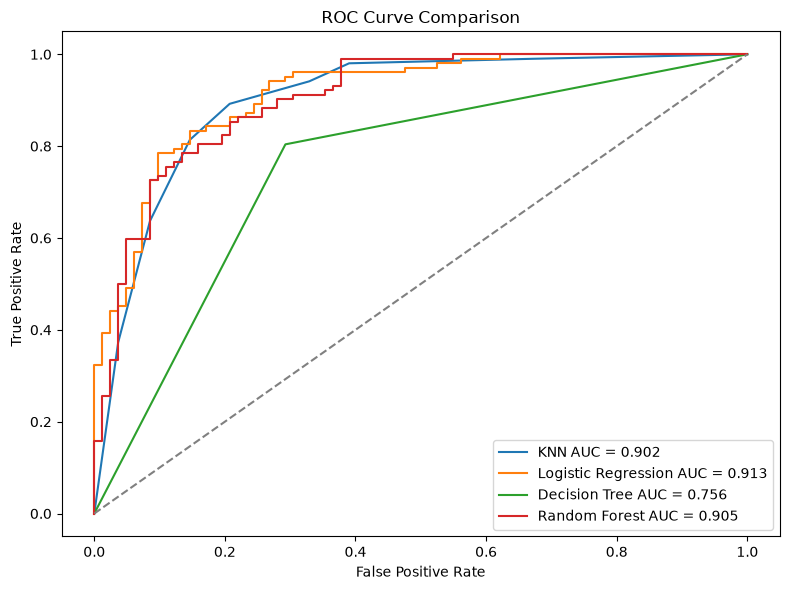

In [8]:
plt.figure(figsize=(8, 6))
roc_rows = []

for model_name, model in models.items():
    if model_name != "Random Forest":
        model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{model_name} AUC = {auc_score:.3f}")
    roc_rows.append(pd.DataFrame({"model": model_name, "fpr": fpr, "tpr": tpr}))

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "roc_curves.png", dpi=300)
plt.show()

all_roc_curves = pd.concat(roc_rows, ignore_index=True)


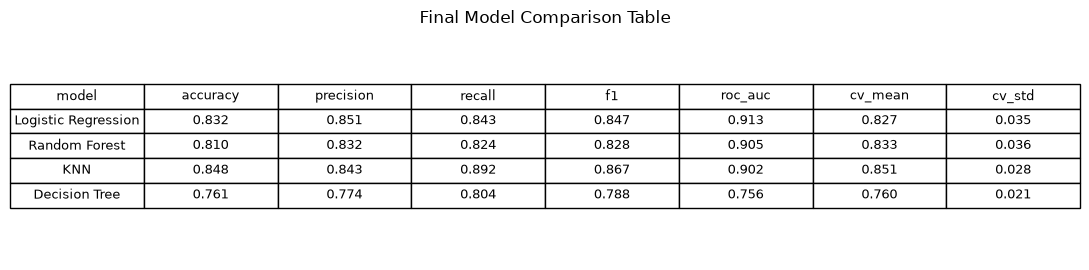

In [9]:
fig, ax = plt.subplots(figsize=(11, 2.8))
ax.axis("off")
display_table = final_model_comparison.copy()
for column in ["accuracy", "precision", "recall", "f1", "roc_auc", "cv_mean", "cv_std"]:
    display_table[column] = display_table[column].map(lambda value: f"{value:.3f}")

table = ax.table(cellText=display_table.values, colLabels=display_table.columns, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)
plt.title("Final Model Comparison Table")
plt.tight_layout()
plt.savefig(figures_dir / "final_results_table.png", dpi=300)
plt.show()


In [10]:
best_model_name = best_model["model"]
best_model_reason = (
    f"{best_model_name} performed best because it achieved the highest ROC-AUC, "
    f"with strong F1-score and stable cross-validation performance."
)
best_model_reason


'Logistic Regression performed best because it achieved the highest ROC-AUC, with strong F1-score and stable cross-validation performance.'

In [11]:
final_model_comparison.to_csv(results_dir / "final_model_comparison.csv", index=False)
all_roc_curves.to_csv(results_dir / "all_roc_curves.csv", index=False)
